In [1]:
import os
import json
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

In [2]:
os.chdir('..')

In [3]:
rmse_frame = pd.read_csv('./data/error_frame.csv')

In [4]:
K_GRID = {20, 40, 60}
OSA_GRID = {0, 20, 40, 60}
ELO_NAMES = {'_c_k_{}_osa_{}'.format(k, osa) for k in K_GRID for osa in OSA_GRID}
ELO_NAMES = {'_c_k_{}_osa_{}'.format(k, osa) for k in K_GRID for osa in OSA_GRID}
ELO_NAMES.update({name + '_trin' for name in ELO_NAMES})
ELO_NAMES.update({'default', 'historic_wins_share', 'season_wins_share', 'blind'})
ERROR_NAMES = {name + '_error' for name in ELO_NAMES}

In [5]:
summary_rmse = pd.DataFrame.from_dict({i: {'error': name, 'score': rmse_frame[name].mean() ** .5} for i, name in enumerate(ERROR_NAMES)}, orient='index')
summary_rmse.sort_values(['score'])

,error,score
25,default_error,0.161929
2,_c_k_60_osa_20_error,0.162152
12,_c_k_60_osa_40_error,0.162815
19,_c_k_60_osa_60_error,0.163906
5,_c_k_20_osa_20_trin_error,0.163976
24,_c_k_40_osa_20_error,0.164181
8,_c_k_40_osa_40_error,0.164627
17,_c_k_20_osa_40_trin_error,0.165284
3,_c_k_40_osa_60_error,0.165412
10,_c_k_60_osa_0_error,0.167098


In [6]:
annual_summary = rmse_frame.groupby('season').agg({name: ['mean'] for name in ERROR_NAMES}) ** .5

In [7]:
annual_summary

,_c_k_20_osa_60_trin_error,_c_k_20_osa_0_error,_c_k_60_osa_20_error,_c_k_40_osa_60_error,_c_k_20_osa_20_error,_c_k_20_osa_20_trin_error,historic_wins_share_error,_c_k_20_osa_0_trin_error,_c_k_40_osa_40_error,_c_k_60_osa_20_trin_error,...,_c_k_40_osa_20_trin_error,_c_k_60_osa_60_error,blind_error,_c_k_40_osa_0_trin_error,_c_k_20_osa_40_error,_c_k_40_osa_60_trin_error,_c_k_40_osa_20_error,default_error,season_wins_share_error,_c_k_60_osa_60_trin_error
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
season,,,,,,,,,,,,,,,,,,,,,
2014,0.078162,0.084071,0.072385,0.076461,0.084071,0.078162,0.225880,0.078162,0.076461,0.145271,...,0.114054,0.072385,0.098301,0.114054,0.084071,0.114054,0.076461,0.072385,0.225880,0.145271
2015,0.192097,0.188650,0.186359,0.186562,0.190233,0.190669,0.278074,0.195230,0.186942,0.201807,...,0.194427,0.185534,0.195617,0.206350,0.189867,0.198540,0.187411,0.186921,0.258171,0.206667
2016,0.065086,0.062105,0.052990,0.057010,0.062475,0.063544,0.281401,0.089250,0.056502,0.140604,...,0.105939,0.054373,0.072564,0.134767,0.062205,0.108399,0.056500,0.053306,0.180971,0.143524
2017,0.184958,0.196140,0.185418,0.187942,0.194643,0.181362,0.306573,0.198957,0.187969,0.197119,...,0.185429,0.185200,0.209270,0.217168,0.194522,0.194749,0.188138,0.185686,0.228657,0.208667
2018,0.185562,0.184741,0.177931,0.181132,0.184774,0.178638,0.278516,0.206382,0.180306,0.198685,...,0.185535,0.180358,0.195105,0.221433,0.184357,0.195775,0.180067,0.177692,0.230666,0.209710
2019,0.205675,0.210898,0.195318,0.202255,0.203581,0.195309,0.327377,0.227342,0.199770,0.206635,...,0.197779,0.199845,0.214788,0.247652,0.204940,0.215084,0.197921,0.194184,0.246552,0.224993
2020,0.197309,0.186897,0.181080,0.186558,0.185591,0.191066,0.334139,0.219326,0.184530,0.207269,...,0.198412,0.186011,0.190097,0.241583,0.186136,0.213041,0.182831,0.179641,0.247867,0.224903
2021,0.164191,0.170376,0.165011,0.166919,0.171539,0.163186,0.289546,0.181447,0.166497,0.180783,...,0.168169,0.166229,0.184556,0.187993,0.171222,0.171582,0.166454,0.165197,0.218253,0.185162


In [8]:
annual_summary.idxmin(axis=1)

season
2014         (_c_k_60_osa_20_error, mean)
2015          (_c_k_60_osa_0_error, mean)
2016         (_c_k_60_osa_20_error, mean)
2017    (_c_k_20_osa_20_trin_error, mean)
2018                (default_error, mean)
2019                (default_error, mean)
2020                (default_error, mean)
2021    (_c_k_20_osa_40_trin_error, mean)
dtype: object

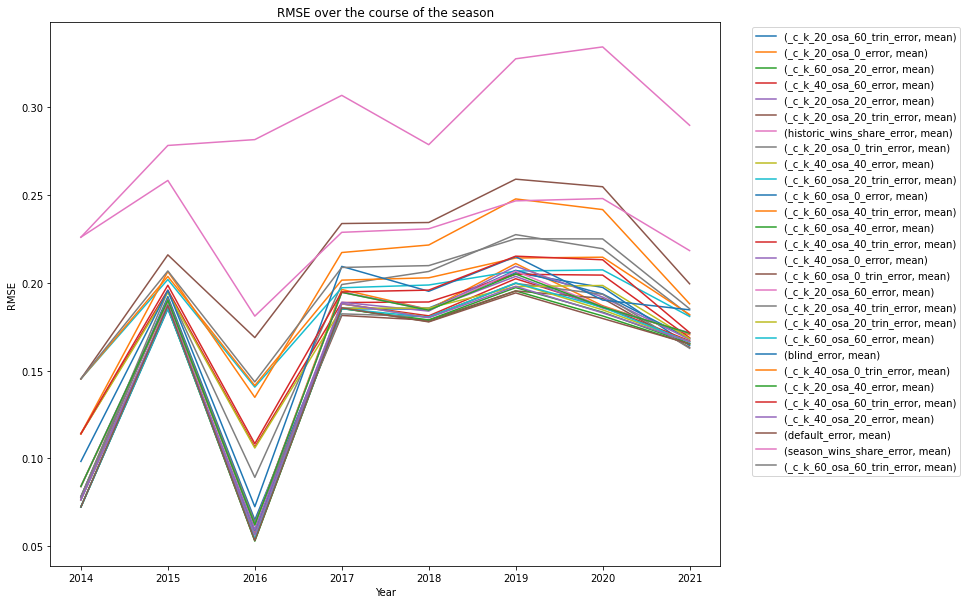

In [11]:
annual_summary.plot.line(figsize=(12,10))
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel('Year')
plt.ylabel('RMSE')
plt.title('RMSE over the course of the season')
plt.show()

In [12]:
weekly_summary = rmse_frame.groupby('week').agg({name: ['mean'] for name in ERROR_NAMES}) ** .5

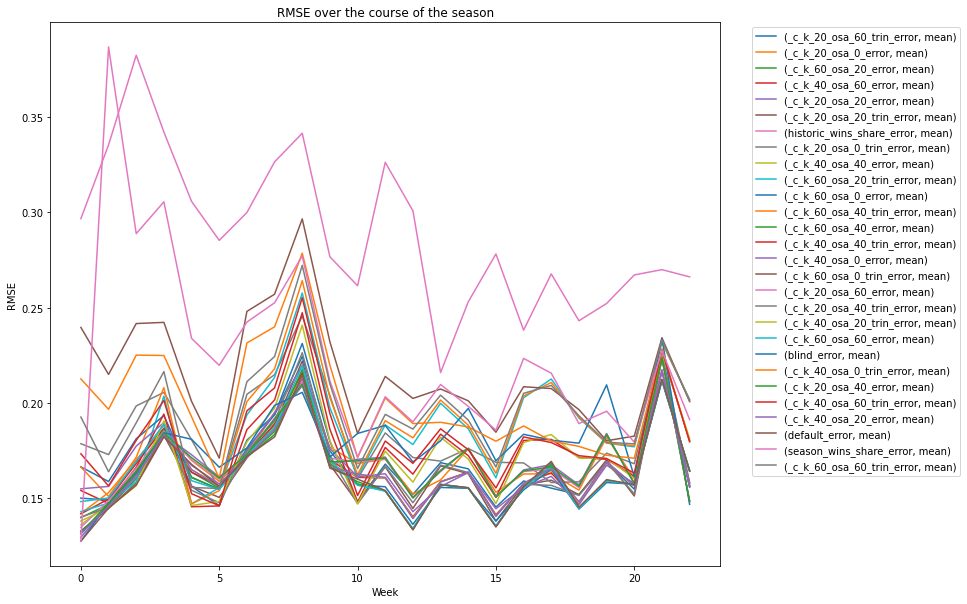

In [13]:
weekly_summary.loc[0:22].plot.line(figsize=(12,10))
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel('Week')
plt.ylabel('RMSE')
plt.title('RMSE over the course of the season')
plt.show()

In [14]:
weekly_summary.idxmin(axis=1)

week
0                   (blind_error, mean)
1     (_c_k_20_osa_20_trin_error, mean)
2     (_c_k_40_osa_20_trin_error, mean)
3                 (default_error, mean)
4     (_c_k_40_osa_40_trin_error, mean)
5     (_c_k_40_osa_40_trin_error, mean)
6     (_c_k_20_osa_20_trin_error, mean)
7                 (default_error, mean)
8                   (blind_error, mean)
9                 (default_error, mean)
10    (_c_k_40_osa_20_trin_error, mean)
11         (_c_k_60_osa_40_error, mean)
12                (default_error, mean)
13          (_c_k_60_osa_0_error, mean)
14          (_c_k_60_osa_0_error, mean)
15                (default_error, mean)
16          (_c_k_60_osa_0_error, mean)
17    (_c_k_20_osa_60_trin_error, mean)
18          (_c_k_60_osa_0_error, mean)
19          (_c_k_60_osa_0_error, mean)
20    (_c_k_20_osa_20_trin_error, mean)
21          (_c_k_60_osa_0_error, mean)
22                  (blind_error, mean)
23    (_c_k_40_osa_60_trin_error, mean)
dtype: object

In [15]:
Counter(weekly_summary.idxmin(axis=1))

Counter({('blind_error', 'mean'): 3,
         ('_c_k_20_osa_20_trin_error', 'mean'): 3,
         ('_c_k_40_osa_20_trin_error', 'mean'): 2,
         ('default_error', 'mean'): 5,
         ('_c_k_40_osa_40_trin_error', 'mean'): 2,
         ('_c_k_60_osa_40_error', 'mean'): 1,
         ('_c_k_60_osa_0_error', 'mean'): 6,
         ('_c_k_20_osa_60_trin_error', 'mean'): 1,
         ('_c_k_40_osa_60_trin_error', 'mean'): 1})

In [16]:
smaller_summary = rmse_frame[['default_error', '_c_k_60_osa_60_error', '_c_k_60_osa_40_error', '_c_k_60_osa_20_error', '_c_k_20_osa_20_trin_error', 'blind_error', 'season_wins_share_error', 'historic_wins_share_error', 'week']].groupby('week').agg({name: ['mean'] for name in ERROR_NAMES if name in ['default_error', '_c_k_60_osa_60_error', '_c_k_60_osa_40_error', '_c_k_60_osa_20_error', '_c_k_20_osa_20_trin_error', 'blind_error', 'season_wins_share_error', 'historic_wins_share_error', 'week']}) ** .5

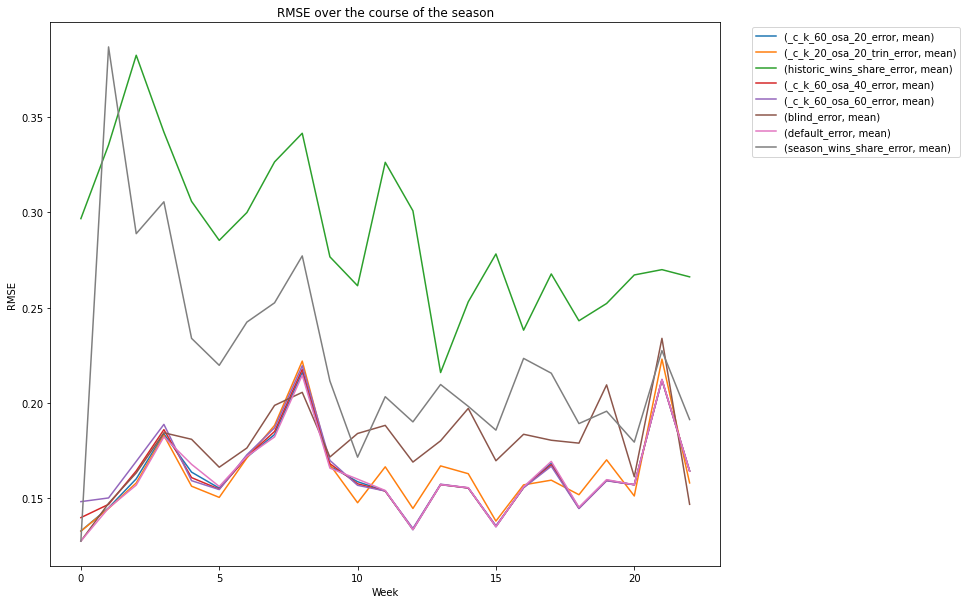

In [17]:
smaller_summary.loc[0:22].plot.line(figsize=(12,10))
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel('Week')
plt.ylabel('RMSE')
plt.title('RMSE over the course of the season')
plt.show()

In [19]:
smaller_summary = rmse_frame[['default_error', '_c_k_60_osa_60_error', '_c_k_60_osa_40_error', '_c_k_60_osa_20_error', '_c_k_20_osa_20_trin_error', 'blind_error', 'season_wins_share_error', 'historic_wins_share_error', 'season']].groupby('season').agg({name: ['mean'] for name in ERROR_NAMES if name in ['default_error', '_c_k_60_osa_60_error', '_c_k_60_osa_40_error', '_c_k_60_osa_20_error', '_c_k_20_osa_20_trin_error', 'blind_error', 'season_wins_share_error', 'historic_wins_share_error', 'season']}) ** .5

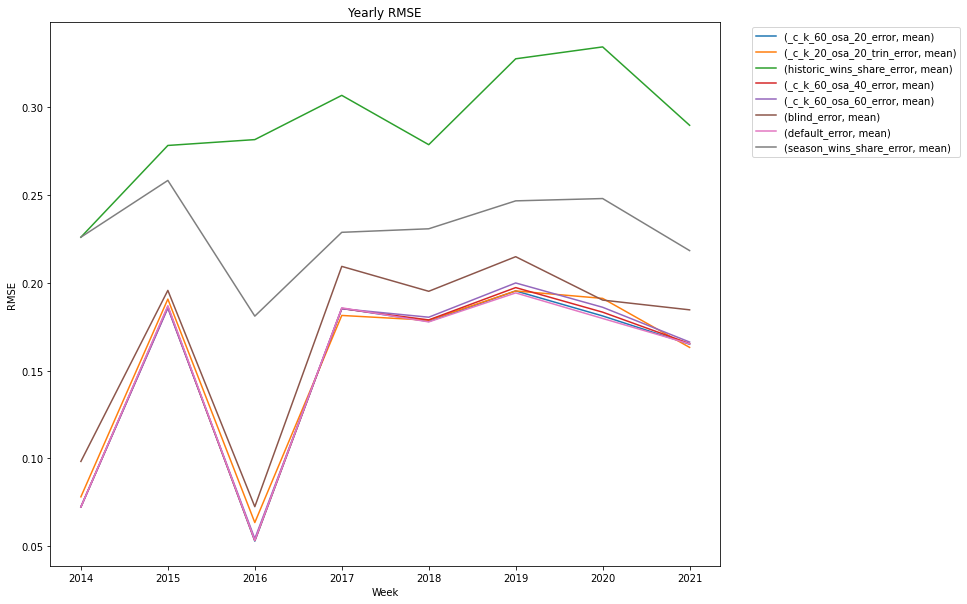

In [22]:
smaller_summary.plot.line(figsize=(12,10))
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel('Year')
plt.ylabel('RMSE')
plt.title('Yearly RMSE')
plt.show()